# 第7〜8回：共分散行列適応進化戦略（Covariance Matrix Adaptation Evolution Strategy, CMA-ES）

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture07_cmaes.ipynb)


```{note}
:class: dropdown
:open: true
この資料は **Jupyter Notebook** として配布する．上から順に Markdown セルで考え方を読み，必要な箇所でコードセルを実行すると，CMA-ES の探索分布がどのように変わるかを確認できる．
```

本ページでは，連続最適化でよく使われる **CMA-ES（Covariance Matrix Adaptation Evolution Strategy）** を扱う．
CMA-ES は **進化戦略（Evolution Strategy; ES）** の代表的手法であり，候補解を多変量正規分布から生成し，良かった個体の情報を使って，分布の **中心**，**広がり**，**向き** を更新していく．

第6回の Differential Evolution（DE）が「個体同士の差分ベクトル」から試行点を作ったのに対し，CMA-ES は「探索分布そのもの」を学習する．この違いを意識しながら読むとよい．



## CMA-ES は何に使われるか

CMA-ES は，画像分類器や言語モデルのように **データから予測器を学習するモデル** ではない．より正確には，**目的関数を小さくする入力値を探すための最適化アルゴリズム** である．

したがって，CMA-ES が出力するものは「この入力なら目的関数値が小さい」という **解候補** であり，「新しいデータを分類するモデル」ではない．この区別は重要である．

CMA-ES が得意なのは，目的関数の中身を直接のぞけない状況である．たとえば「この設定でシミュレーションを 1 回走らせるとスコアが返る」「このハイパーパラメータで交差検証すると精度が返る」という場面では，勾配や式の形を使えない．このように，入力を入れて評価値だけを受け取る問題を **ブラックボックス最適化** と呼ぶ．

CMA-ES は次のような場面で使われる．

- **連続値パラメータのブラックボックス最適化**：関数の中身や勾配は分からないが，入力を与えると評価値だけ返る場合．
- **シミュレーションや工学設計の調整**：機械部品の形状，制御パラメータ，材料設計など，試して評価する処理が中心の問題．
- **機械学習のハイパーパラメータ探索**：SVM の $C$ や $\gamma$，前処理の重み，損失関数の係数などを探索する場合．
- **ロボット制御や強化学習の方策探索**：方策を少数の実数パラメータで表し，試行結果のスコアだけで改善する場合．
- **微分できない・ノイズがある目的関数の最適化**：評価値が揺れる，途中に if 文が多い，勾配が取りにくい，といった問題．

もう 1 つ大事なのは，CMA-ES が評価値の絶対的な大きさよりも **順位** を重視する点である．最小化なら「どの個体が 1 番小さいか」「どれが上位 $\mu$ 個に入るか」を見て，その上位個体から次の探索分布を更新する．つまり，$f(\boldsymbol{x})=0.01$ と $f(\boldsymbol{x})=100$ のような数値そのものより，「どちらが良かったか」が中心である．この性質により，評価値のスケールが扱いにくい問題や，評価値に多少のノイズがある問題でも比較的使いやすい．

一方で，本ページで CMA-ES を TSP やナップサックのような **純粋な組合せ最適化** へ無理に適用する必要はない．CMA-ES はまず，連続値パラメータを調整するブラックボックス最適化の手法として理解すればよい．もちろん，連続ベクトルを順列や 0-1 ベクトルへ変換する設計を入れれば，組合せ最適化に応用することもできる．

```{note} アルゴリズム？モデル？
:class: dropdown
:open: true

本ページでは「CMA-ES というモデル」と呼ぶより，**CMA-ES という連続最適化アルゴリズム** と呼ぶほうが正確である．ただし，探索分布 $\mathcal{N}(\boldsymbol{m},\sigma^2\boldsymbol{C})$ を内部に持つので，「探索分布モデルを更新する手法」と見ることはできる．
```



## 0. このページで学ぶこと

1. CMA-ES が何を最適化しているように見えるか．
2. 探索分布 $\mathcal{N}(\boldsymbol{m}, \sigma^2\boldsymbol{C})$ の意味．
3. 評価値そのものではなく，評価値の **順位** から上位個体を選ぶ考え方．
4. 上位個体による平均 $\boldsymbol{m}$ の更新．
5. 進化パスによるステップサイズ $\sigma$ の更新．
6. 共分散行列 $\boldsymbol{C}$ の更新と，楕円が伸びる直感．
7. 単調変換や座標の回転に対して CMA-ES が比較的強い理由．
8. NumPy による CMA-ES の最小実装．
9. 悪スケールな 2 次元関数での可視化と演習．



(sec:cmaes-ch1)=

## 1. CMA-ES の位置づけ

CMA-ES は，目的関数 $f(\boldsymbol{x})$ の勾配を使わずに

$$
\min_{\boldsymbol{x}\in\mathbb{R}^n} f(\boldsymbol{x})
$$

を解くための確率的な連続最適化手法である．目的関数の中身を知らず，入力と出力だけを見て探索するので，**ブラックボックス最適化**の手法として説明されることが多い．

この式で使っている記号を先に整理しておく．

- $n\in\mathbb{N}$: 変数の個数，つまり探索空間の次元である．
- $\mathbb{R}^n$: $n$ 個の実数を並べたベクトル全体の集合である．たとえば $n=2$ なら平面上の点，$n=10$ なら 10 個の実数パラメータを持つ点を表す．
- $\boldsymbol{x}=(x_1,x_2,\ldots,x_n)^{\top}\in\mathbb{R}^n$: 1 つの解候補である．太字はベクトルを表す．
- $f:\mathbb{R}^n\to\mathbb{R}$: 解候補 $\boldsymbol{x}$ を 1 つの評価値へ写す目的関数である．CMA-ES ではこの値を小さくする $\boldsymbol{x}$ を探す．
- $\min_{\boldsymbol{x}\in\mathbb{R}^n}$: 「$\mathbb{R}^n$ の中から，$f(\boldsymbol{x})$ が最も小さくなる $\boldsymbol{x}$ を探す」という意味である．



### 1.1 何を動かすアルゴリズムか

PSO では粒子の位置と速度を動かした．DE では集団中の個体差分から試行個体を作った．

CMA-ES では，個体そのものよりも **個体を発生させる分布** に注目する．世代 $t$ での候補解を

$$
\boldsymbol{x}_k^{(t)}\sim
\mathcal{N}\!\left(\boldsymbol{m}^{(t)},\left(\sigma^{(t)}\right)^2\boldsymbol{C}^{(t)}\right)
$$

と書く．これは「$t$ 世代目の $k$ 番目の候補解 $\boldsymbol{x}_k^{(t)}$ を，多変量正規分布から 1 つサンプリングする」という意味である．同じ内容を

$$
\boldsymbol{x}_k^{(t)}
=
\boldsymbol{m}^{(t)}+\sigma^{(t)}\boldsymbol{y}_k^{(t)},
\qquad
\boldsymbol{y}_k^{(t)}\sim\mathcal{N}\!\left(\boldsymbol{0},\boldsymbol{C}^{(t)}\right)
$$

と書いてもよい．この式で使う記号は次の通りである．

- $t\in\{0,1,2,\ldots\}$: 世代番号である．上付きの $(t)$ は「$t$ 世代目の値」を表す．
- $k\in\{1,2,\ldots,\lambda\}$: 同じ世代の中で何番目の候補解かを表す添字である．ここでの $k$ は次元ではない．
- $\lambda\in\mathbb{N}$: 1 世代で生成する候補解の個数である．
- $\boldsymbol{x}_k^{(t)}\in\mathbb{R}^n$: $t$ 世代目に生成された $k$ 番目の解候補である．
- $\boldsymbol{m}^{(t)}\in\mathbb{R}^n$: 探索分布の平均ベクトル，つまり中心である．集合ではなく，今どこを狙っているかを表す 1 つの点である．
- $\sigma^{(t)}\in\mathbb{R}_{>0}$: ステップサイズである．全方向に共通する探索幅を表す正の実数である．見た目が似た文字と混同しやすいが，ここでは $\rho$ ではなくギリシャ文字のシグマ $\sigma$ を使う．
- $\boldsymbol{C}^{(t)}\in\mathbb{R}^{n\times n}$: $\sigma^{(t)}$ を除いた **ずれベクトル** $\boldsymbol{y}_k^{(t)}$ の共分散行列である．英語では covariance matrix と呼ぶ．探索分布の形と向きを決める対称な行列で，CMA-ES では正定値行列として扱う．候補解 $\boldsymbol{x}_k^{(t)}$ そのものの共分散行列は $\left(\sigma^{(t)}\right)^2\boldsymbol{C}^{(t)}$ である．
- $\mathcal{N}(\boldsymbol{a},\boldsymbol{\Sigma})$: 平均 $\boldsymbol{a}$，共分散行列 $\boldsymbol{\Sigma}$ の多変量正規分布である．
- $\sim$: 「その分布に従ってランダムに生成される」という意味である．

CMA-ES の見方は単純である．良い個体が出た方向へ中心 $\boldsymbol{m}^{(t)}$ を動かし，うまく進んでいるなら探索幅 $\sigma^{(t)}$ を保つか広げ，目的関数が変化しやすい方向へ共分散行列 $\boldsymbol{C}^{(t)}$ を伸ばす．このとき，CMA-ES が長期的に保持している情報は「過去に出た個体の一覧」ではなく，正規分布のパラメータ $\boldsymbol{m}^{(t)}$，$\sigma^{(t)}$，$\boldsymbol{C}^{(t)}$ である．つまり，探索の記憶を分布の形に押し込めている．

```{important} 順位だけを見るとなぜうれしいのか
:class: dropdown

CMA-ES は，候補解の評価値を小さい順に並べ，上位の個体を使って分布を更新する．そのため，目的関数値そのものの単位やスケールにはあまり依存しない．たとえば，$f(\boldsymbol{x})$ を $2f(\boldsymbol{x})+10$ に変えても，また $\exp(f(\boldsymbol{x}))$ のように大小関係を保つ変換をしても，個体の順位が同じなら，上位個体の選ばれ方は同じである．

これは「評価値の数字を細かく信じる」のではなく，「どれが相対的に良かったか」を信じる設計である．シミュレーションのスコアにノイズがある場合や，目的関数のスケールが場所によって大きく変わる場合に，この性質は扱いやすさにつながる．ただし，ノイズで順位そのものが頻繁に入れ替わるほど激しい場合には，当然ながら探索は難しくなる．
```



### 1.2 組合せ最適化との関係

CMA-ES は基本的には **連続変数に対する最適化手法** である．したがって，本ページでは TSP やナップサックのような離散問題へ直接適用する例は扱わない．ここでは，CMA-ES を「連続値パラメータを調整するブラックボックス最適化」として理解することを優先する．

ただし，応用できないという意味ではない．たとえば TSP では，第5回 ACO の課題で触れた Random Keys のように，実数ベクトルの順位を訪問順序に変換すれば，CMA-ES が更新する連続ベクトルと，実際に評価する巡回路をつなげられる．この場合，CMA-ES が直接見ているのは連続空間であり，組合せ構造そのものではない点に注意する．



(sec:cmaes-ch2)=

## 2. アルゴリズムの全体像

CMA-ES の 1 世代は，おおまかに次の流れである．

1. 現在の分布から $\lambda$ 個体をサンプリングする．
2. 各個体の目的関数値を計算する．
3. 目的関数値が良い順に個体を並べる．
4. 値の良い上位 $\mu$ 個体を選ぶ．
5. 上位個体の重み付き平均で中心 $\boldsymbol{m}$ を更新する．
6. 中心の移動方向を進化パスとして蓄積し，$\sigma$ と $\boldsymbol{C}$ を更新する．

ここから先は，1 世代の中で何が起きるかに注目する．そのため，表記を軽くする目的で，世代を表す上付き添字 $^{(t)}$ は省略する．たとえば厳密には $\boldsymbol{m}^{(t)}$，$\sigma^{(t)}$，$\boldsymbol{C}^{(t)}$，$\boldsymbol{x}_k^{(t)}$ と書けるが，以下では同じ世代の値を $\boldsymbol{m}$，$\sigma$，$\boldsymbol{C}$，$\boldsymbol{x}_k$ と書く．次の世代へ更新された値を強調したいときだけ，必要に応じて「更新後」や $t+1$ 世代目という言い方を使う．

ここで $\lambda\in\mathbb{N}$ は 1 世代で生成する個体数，$\mu\in\{1,2,\ldots,\lambda\}$ は次の更新に使う上位個体数である．典型的には $\mu=\left\lfloor \dfrac{\lambda}{2}\right\rfloor$ とし，順位の高い個体ほど大きな重みを与える．

```{hint} 床関数と天井関数：$\left\lfloor \text{数字} \right\rfloor$，$\left\lceil \text{数字} \right\rceil$ の読み方
:class: dropdown

$\left\lfloor \dfrac{\lambda}{2}\right\rfloor$ のように，左右に下向きの角が付いた記号は $\overset{\text{ゆか}}{\text{床}}\text{関数}$ と呼ばれる．

$\overset{\text{ゆか}}{\text{床}}\text{関数}$ は「中にある数を超えない最大の整数」を返す関数である．言い換えると，数直線上でその数と同じ位置か，それより左側にある整数のうち，いちばん近いものを選ぶ．

床関数の例を並べると，次のようになる．

1. $\left\lfloor 1.2 \right\rfloor=1$
2. $\left\lfloor 4.8 \right\rfloor=4$
3. $\left\lfloor \sqrt{10} \right\rfloor=3$
4. $\left\lfloor -1.1 \right\rfloor=-2$
5. $\left\lfloor -6.02 \right\rfloor=-7$

ここで注意したいのは，床関数は単なる「小数点以下を捨てる」操作ではないという点である．正の数なら $\left\lfloor 4.8\right\rfloor=4$ なので切り捨てに見えるが，負の数では $\left\lfloor -6.02\right\rfloor=-7$ になる．$-6$ ではなく，$-6.02$ を超えない整数のうち最大のものが $-7$ だからである．

一方，左右に上向きの角が付いた $\left\lceil \cdot \right\rceil$ は $\overset{\text{てんじょう}}{\text{天井}}\text{関数}$ と呼ばれる．天井関数は「中にある数以上の最小の整数」を返す関数である．数直線上でその数と同じ位置か，それより右側にある整数のうち，いちばん近いものを選ぶ．

天井関数の例も見ておこう．

1. $\left\lceil 1.2 \right\rceil=2$
2. $\left\lceil 4.8 \right\rceil=5$
3. $\left\lceil \sqrt{10} \right\rceil=4$
4. $\left\lceil -1.1 \right\rceil=-1$
5. $\left\lceil -6.02 \right\rceil=-6$

Python では，標準ライブラリの `math.floor` が床関数，`math.ceil` が天井関数に対応する．配列にまとめて適用したいときは，NumPy の `np.floor`，`np.ceil` を使うとよい．

~~~python
import math

math.floor(4.8)     # 4
math.floor(-6.02)   # -7
math.ceil(1.2)      # 2
math.ceil(-6.02)    # -6
~~~

なお，Python の `int(-6.02)` は `-6` になる．これは 0 に近い方向へ小数部分を取り除く変換なので，負の数では床関数 `math.floor(-6.02)` とは結果が異なる．
```

この節では，変数の次元を $n$ と書き，個体番号を $k$ と書く．したがって $\boldsymbol{x}_k\in\mathbb{R}^n$ であり，$\mathbb{R}^k$ ではない．$k$ は「何番目の個体か」を表す添字である．

また，CMA-ES では個体を目的関数値で並べ替えた後の記号がよく出る．最小化問題では，並べ替え後の個体を

$$
f(\boldsymbol{x}_{1:\lambda})
\leq
f(\boldsymbol{x}_{2:\lambda})
\leq
\cdots
\leq
f(\boldsymbol{x}_{\lambda:\lambda})
$$

となるように書く．$\boldsymbol{x}_{1:\lambda}$ は「$\lambda$ 個体の中で 1 番良かった個体」，$\boldsymbol{x}_{2:\lambda}$ は「2 番目に良かった個体」である．この記法を理解しておくと，後の $\boldsymbol{y}_{i:\lambda}$ や $w_i$ の意味が読みやすくなる．



### 2.1 サンプリング

> 1. 現在の分布から $\lambda$ 個体をサンプリングする．

この節でやりたいことは，$\lambda$ 個の候補解 $\boldsymbol{x}_1,\ldots,\boldsymbol{x}_{\lambda}$ を，現在の探索分布

$$
\boldsymbol{x}_k\sim\mathcal{N}(\boldsymbol{m},\sigma^2\boldsymbol{C})
$$

から作ることである．ここで $k=1,2,\ldots,\lambda$ は個体番号である．記号 $\sim$ は等号ではなく，「その分布に従って生成する」という意味で読む．

ここで $\boldsymbol{C}$ は，中心 $\boldsymbol{m}$ からの **ずれベクトル** $\boldsymbol{y}_k$ の共分散行列である．つまり

$$
\boldsymbol{y}_k=\dfrac{\boldsymbol{x}_k-\boldsymbol{m}}{\sigma},
\qquad
\operatorname{Cov}(\boldsymbol{y}_k)=\boldsymbol{C}
$$

という意味である．一方，候補解 $\boldsymbol{x}_k$ そのものの共分散行列は $\sigma^2\boldsymbol{C}$ である．したがって，$\boldsymbol{C}$ は「全体の大きさ $\sigma$ を除いた，探索分布の形と向き」を表している．

実装では，いきなり $\boldsymbol{x}_k$ を作るのではなく，次の 3 段階に分けると理解しやすい．

1. 原点中心の丸い乱数 $\boldsymbol{z}_k$ を作る．
2. $\boldsymbol{z}_k$ を **ずれベクトルの共分散行列** $\boldsymbol{C}$ の形に合わせて変形し，**ずれベクトル** $\boldsymbol{y}_k$ を作る．
3. 楕円形の **ずれベクトル** $\boldsymbol{y}_k$ を $\sigma$ 倍し，それを現在の中心 $\boldsymbol{m}$ に足して，候補解 $\boldsymbol{x}_k$ にする．

2 番目の「形に合わせて変形する」は，次の図のように考えるとよい．左の丸い点群が $\boldsymbol{z}_k$ である．まず $\boldsymbol{D}$ によって，今見ている座標軸のまま方向ごとの長さだけを変える．次に $\boldsymbol{B}$ によって，その伸縮後の楕円の軸そのものを回転させる．その結果，右のような楕円形の **ずれベクトル** $\boldsymbol{y}_k$ になる．

:::::{div}
:class: cmaes-sampling-scroll

::::{div}
:class: cmaes-sampling-overlay

![丸い標準正規乱数を伸縮・回転して楕円形のずれベクトルに変換する図](assets/lecture07_cmaes_sampling_transform.svg)

:::{div}
:class: cmaes-sampling-label cmaes-sampling-label-left
$\boldsymbol{z}_k\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$
:::

:::{div}
:class: cmaes-sampling-label cmaes-sampling-label-middle
$\boldsymbol{D}\boldsymbol{z}_k$
:::

:::{div}
:class: cmaes-sampling-label cmaes-sampling-label-right
$\boldsymbol{y}_k=\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k$
:::

::::
:::::

図の左は丸い標準正規乱数 $\boldsymbol{z}_k$，中央は $\boldsymbol{D}$ で方向ごとに伸縮した点群，右は $\boldsymbol{B}$ で楕円の軸を回転した **ずれベクトル** $\boldsymbol{y}_k=\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k$ である．同じ色の点は同じ乱数サンプルを表しており，形だけが変わっている．

$\boldsymbol{D}$ と $\boldsymbol{B}$ の役割は，次のように分けて覚えるとよい．$\boldsymbol{D}$ は「どの方向にどれだけ長くするか」を決めるが，軸の向きはまだ変えない．$\boldsymbol{B}$ は中心を動かす行列ではなく，伸縮でできた楕円の軸をどちらへ向けるかを決める行列である．

図中の対応関係を数式で書くと次のようになる．

| 図の位置 | 数式 | 直感 |
|---|---|---|
| 左 | $\boldsymbol{z}_k\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$ | 原点中心の丸い乱数 |
| 中央 | $\boldsymbol{D}\boldsymbol{z}_k$ | 座標軸の向きはそのまま，方向ごとの長さだけを変えた点群 |
| 右 | $\boldsymbol{y}_k=\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k$ | 伸縮後の楕円の軸を回転させた **ずれベクトル** |

```{important} なぜ $\boldsymbol{D}$ が「長さを変える」作用になるの？
:class: dropdown
:open: true

なぜ $\boldsymbol{D}$ が「長さを変える」作用になるのだろうか．$\boldsymbol{D}$ は対角行列なので，たとえば 2 次元なら

$$
\boldsymbol{D}=
\begin{pmatrix}
d_1 & 0\\
0 & d_2
\end{pmatrix},
\qquad
\boldsymbol{D}
\begin{pmatrix}
z_1\\
z_2
\end{pmatrix}
=
\begin{pmatrix}
d_1z_1\\
d_2z_2
\end{pmatrix}
$$

となる．第 1 成分には $d_1$，第 2 成分には $d_2$ を掛けているだけで，成分同士を混ぜていない．そのため，横方向と縦方向の長さは変わるが，軸の向きはまだ変わらない．これが「$\boldsymbol{D}$ は方向ごとの長さを変える」という意味である．

```

```{important} なぜ $\boldsymbol{B}$ が「軸の向きを変える」作用になるの？
:class: dropdown
:open: true

一方，$\boldsymbol{B}$ は固有ベクトルを列に並べた直交行列である．2 次元なら

$$
\boldsymbol{B}=\begin{pmatrix} \boldsymbol{b}_1 & \boldsymbol{b}_2 \end{pmatrix},
\qquad
\boldsymbol{B}
\begin{pmatrix}
u_1\\
u_2
\end{pmatrix}
=u_1\boldsymbol{b}_1+u_2\boldsymbol{b}_2
$$

と読める．ここで $u_1,u_2$ は $\boldsymbol{D}\boldsymbol{z}_k$ の各成分である．つまり，もともとの第 1 軸の方向を $\boldsymbol{b}_1$ 方向へ，第 2 軸の方向を $\boldsymbol{b}_2$ 方向へ写している．$\boldsymbol{B}$ は直交行列なので，長さや角度を勝手に伸ばすのではなく，軸の向きを変える役割を持つ．ここでいう「軸をずらす」は，中心を平行移動させるという意味ではなく，楕円の長い軸・短い軸の向きを変えるという意味である．
```

したがって，$\boldsymbol{D}$ で作った横長・縦長の楕円を，$\boldsymbol{B}$ によって斜め方向へ向ける，と考えればよい．

$$
\overbrace{\boldsymbol{z}_k\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})}^{\text{丸い乱数}}
\quad\Longrightarrow\quad
\overbrace{\boldsymbol{y}_k=\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k}^{\text{楕円形のずれベクトル}}
\quad\Longrightarrow\quad
\overbrace{\boldsymbol{x}_k=\boldsymbol{m}+\sigma\boldsymbol{y}_k}^{\text{中心にずれベクトルを足した候補解}}
$$

ここで $\boldsymbol{z}_k,\boldsymbol{y}_k,\boldsymbol{x}_k\in\mathbb{R}^n$，$\boldsymbol{0}\in\mathbb{R}^n$，$\boldsymbol{I}\in\mathbb{R}^{n\times n}$ である．

```{hint} VAE の Reparameterization Trick でもこういう変形があったような... （こじつけかも）
:class: dropdown

VAE では，まず $\boldsymbol{\epsilon}\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$ という標準正規乱数を作り，その後 $\boldsymbol{z}=\boldsymbol{\mu}+\boldsymbol{\sigma}\odot\boldsymbol{\epsilon}$ のように平均と分散で変形する．CMA-ES でも，まず $\boldsymbol{z}_k\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$ という丸い乱数を作り，$\boldsymbol{x}_k=\boldsymbol{m}+\sigma\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k$ のように探索分布の中心・大きさ・向きへ変形する．

違いは目的である．VAE の Reparameterization Trick は，乱数を含む計算でも勾配を流しやすくするための工夫である．一方，CMA-ES では勾配を流すためではなく，「標準正規乱数を，現在の探索分布 $\mathcal{N}(\boldsymbol{m},\sigma^2\boldsymbol{C})$ に従う候補解へ変換する」ためにこの形で書いている．
```

この流れの中で，$\boldsymbol{B}\boldsymbol{D}$ が「丸い乱数を楕円形に変形する」役割を持つ．そのために，現在の **ずれベクトルの共分散行列** を

$$
\boldsymbol{C}=\boldsymbol{B}\boldsymbol{D}^2\boldsymbol{B}^{\top}
$$

と固有値分解する．ここで $\boldsymbol{C}\in\mathbb{R}^{n\times n}$，$\boldsymbol{B}\in\mathbb{R}^{n\times n}$，$\boldsymbol{D}\in\mathbb{R}^{n\times n}$ である．$\boldsymbol{B}$ は楕円をどちらへ傾けるかを決める行列，$\boldsymbol{D}$ は楕円を各方向へどれくらい伸ばすかを決める対角行列である．より厳密には，$\boldsymbol{B}$ は固有ベクトルを並べた直交行列，$\boldsymbol{D}$ は固有値の平方根を対角成分にもつ対角行列である．

```{hint} なぜ $\boldsymbol{D}^2$ と $\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k$ がつながるのか
:class: dropdown

$\boldsymbol{z}_k\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$ なので，$\boldsymbol{z}_k$ の共分散行列は $\boldsymbol{I}$ である．これに $\boldsymbol{B}\boldsymbol{D}$ を掛けて $\boldsymbol{y}_k=\boldsymbol{B}\boldsymbol{D}\boldsymbol{z}_k$ とすると，$\boldsymbol{y}_k$ の共分散行列は

$$
\operatorname{Cov}(\boldsymbol{y}_k)
=\boldsymbol{B}\boldsymbol{D}\boldsymbol{I}\boldsymbol{D}\boldsymbol{B}^{\top}
=\boldsymbol{B}\boldsymbol{D}^2\boldsymbol{B}^{\top}
=\boldsymbol{C}
$$

となる．つまり，$\boldsymbol{B}\boldsymbol{D}$ を掛けることで，丸い乱数を「共分散行列 $\boldsymbol{C}$ を持つ **ずれベクトル**」に変形できる．
```

```{hint} ずれベクトルの意味
:class: dropdown

ここでいう **ずれベクトル（deviation vector）** は，「現在の探索中心 $\boldsymbol{m}$ から，候補解がどちら向きにどれだけ離れているか」を表すベクトルである．ただし，日常語の「位置のズレ」ではなく，CMA-ES がその時点で持っている平均ベクトル $\boldsymbol{m}$ を基準にした相対的な **ずれベクトル** である．式で見ると，$\sigma\boldsymbol{y}_k$ が実際の移動量を表す **ずれベクトル**，$\boldsymbol{y}_k$ がステップサイズ $\sigma$ を取り除いた **ずれベクトル** である．
```



### 2.2 中心の更新

> 5. 上位個体の重み付き平均で中心 $\boldsymbol{m}$ を更新する．

目的関数値が小さい順に個体を並べ，上位 $\mu$ 個体の **ずれベクトル** $\boldsymbol{y}_{i:\lambda}$ を重み付き平均して $\boldsymbol{y}_w\in\mathbb{R}^n$ を作る．

$$
\boldsymbol{y}_w=\sum_{i=1}^{\mu} w_i \boldsymbol{y}_{i:\lambda},
\qquad
\boldsymbol{m}\leftarrow \boldsymbol{m}+\sigma \boldsymbol{y}_w
$$

$w_i\in\mathbb{R}_{>0}$ は順位が良いほど大きい重みで，$\displaystyle\sum_{i=1}^{\mu}w_i=1$ とする．つまり $\boldsymbol{y}_w$ は上位個体の平均的な移動方向である．この更新だけを見ると，「良かった点の方向へ分布中心を動かす」処理である．

標準的な CMA-ES では，まず順位だけから仮の重み

$$
\tilde{w}_i=\log\!\left(\mu+\dfrac{1}{2}\right)-\log i
\qquad (i=1,2,\ldots,\mu)
$$

を作り，その後

$$
w_i=\dfrac{\tilde{w}_i}{\displaystyle\sum_{j=1}^{\mu}\tilde{w}_j}
$$

で正規化することが多い．$i=1$ が最も良かった個体なので，$\log i$ が最も小さく，$\tilde{w}_1$ が最も大きくなる．$i$ が大きくなるほど順位が下がり，重みも小さくなる．

```{hint} $w_i$ は評価値から計算しているのか
:class: dropdown

$w_i$ は「何番目に良かったか」から事前に決める順位重みである．評価値そのもの，たとえば $f(\boldsymbol{x})=0.01$ や $100$ という数値を直接重みに変換しているわけではない．最後に正規化するので，重みの合計は必ず 1 になる．
```

ここで注意したいのは，$w_i$ は $i$ 番目という **順位** に付く重みであり，評価値 $f(\boldsymbol{x}_{i:\lambda})$ の数値をそのまま使う重みではない，という点である．評価値が 0.01 か 100 かよりも，上位に入ったかどうか，何番目に良かったかが更新に影響を与える．

重みの偏りを表す量として，CMA-ES では有効選択数

$$
\mu_{\mathrm{eff}}=\dfrac{1}{\displaystyle\sum_{i=1}^{\mu}w_i^2}
$$

もよく使う．全員に同じ重みを与えるほど $\mu_{\mathrm{eff}}$ は大きくなり，少数の上位個体に強く依存するほど小さくなる．



### 2.3 ステップサイズの更新

> 6. 中心の移動方向を進化パスとして蓄積し，$\sigma$ と $\boldsymbol{C}$ を更新する．

中心の移動が同じ方向に続くなら，まだ谷に沿って進んでいる可能性が高い．逆に，移動方向が毎世代ばらばらなら，すでに近辺をランダムに揺れているだけかもしれない．


次のアニメーションでは，左に「中心の移動方向がそろっている場合」，右に「中心が近辺でばらばらに動いている場合」を並べる．赤い線は直近の中心移動，青い点はその世代で出た候補解，黒い線はこれまでの中心の軌跡である．

左のように移動方向がそろうと，進化パスは長くなりやすい．右のように移動方向が打ち消し合うと，進化パスはあまり長くならない．この違いを，CMA-ES はステップサイズ $\sigma$ を調整する手がかりとして使う．


In [1]:
from IPython.display import HTML

CMAES_STEP_SIZE_ANIMATION_URL = "https://rsimd.github.io/NITIC-ConbinatorialOptimization/assets/lecture07_cmaes_step_size_animation.html?v=20260527-controls2"

HTML(
    f"""
    <iframe
      class="cmaes-step-size-frame"
      src="{CMAES_STEP_SIZE_ANIMATION_URL}"
      title="中心移動と進化パスの Plotly アニメーション"
      loading="lazy"
    ></iframe>
    """
)



その判定のために，CMA-ES は **進化パス** $\boldsymbol{p}_{\sigma}\in\mathbb{R}^n$ を使う．これは中心移動の指数移動平均のような量である．

$$
\overbrace{\boldsymbol{p}_{\sigma}}^{\text{新しい進化パス}}
\leftarrow
\overbrace{(1-c_{\sigma})\boldsymbol{p}_{\sigma}}^{\text{前回までの記憶}}
+
\overbrace{\sqrt{c_{\sigma}(2-c_{\sigma})\mu_{\mathrm{eff}}}}^{\text{長さをそろえる係数}}\,
\overbrace{\boldsymbol{C}^{-\frac{1}{2}}\boldsymbol{y}_w}^{\text{正規化した移動}}
$$

記号を 1 つずつ読むと，次のようになる．

- $\boldsymbol{p}_{\sigma}\in\mathbb{R}^n$: ステップサイズ更新用の進化パスである．過去から現在まで，中心がどの方向へ続けて動いているかを蓄積する．
- $c_{\sigma}\in(0,1]$: 進化パスをどれくらい早く更新するかを決める学習率である．大きいほど新しい移動を強く反映する．
- $(1-c_{\sigma})\boldsymbol{p}_{\sigma}$: 前回までの進化パスを少し残す項である．指数移動平均の「古い記憶」に対応する．
- $\mu_{\mathrm{eff}}\in\mathbb{R}_{>0}$: 有効選択数である．上位 $\mu$ 個体の重みがどれくらい広く分散しているかを表す．
- $\boldsymbol{C}^{-\frac{1}{2}}\in\mathbb{R}^{n\times n}$: 共分散行列 $\boldsymbol{C}$ の影響を取り除く行列である．探索分布の楕円の伸び縮みをいったん打ち消して，移動方向を比べやすくする．
- $\boldsymbol{y}_w\in\mathbb{R}^n$: 上位個体の重み付き平均で得た **ずれベクトル** である．

つまり $\boldsymbol{C}^{-\frac{1}{2}}\boldsymbol{y}_w$ は，「現在の探索分布の形で見て，どの方向へどれだけ進んだか」を測るための正規化された移動量だと考えればよい．

その長さが，ランダムウォークで期待される長さより大きければ $\sigma$ を大きくし，小さければ $\sigma$ を小さくする．



### 2.4 共分散行列の更新

共分散行列 $\boldsymbol{C}\in\mathbb{R}^{n\times n}$ は，$\sigma$ を除いた **ずれベクトル** の共分散行列であり，探索分布の形を決める．2 次元なら楕円の向きと軸の長さである．候補解そのものの広がりは $\sigma^2\boldsymbol{C}$ で決まる．

CMA-ES では，主に次の 2 つの情報で $\boldsymbol{C}$ を更新する．

- **rank-one update**: 進化パス $\boldsymbol{p}_c\in\mathbb{R}^n$ の方向へ楕円を伸ばす．過去から見て「この方向へ続けて進んでいる」という情報を使う．
- **rank-$\mu$ update**: 現世代の上位 $\mu$ 個体の散らばりから楕円を推定する．今の世代で「良かった個体がどの方向に散らばっていたか」を使う．

簡略化して書けば，

$$
\overbrace{\boldsymbol{C}}^{\text{新しい共分散行列}}
\leftarrow
\overbrace{(1-c_1-c_{\mu})\boldsymbol{C}}^{\text{古い形を残す}}
\quad+
\underbrace{\overbrace{c_1\boldsymbol{p}_c\boldsymbol{p}_c^{\top}}^{\text{進化パスの外積}}}_{\text{第2項: rank-one update}}
\quad+
\underbrace{\overbrace{c_{\mu}\displaystyle\sum_{i=1}^{\mu} w_i
\boldsymbol{y}_{i:\lambda}\boldsymbol{y}_{i:\lambda}^{\top}}^{\text{上位個体の外積平均}}}_{\text{第3項: rank-}\mu\text{ update}}
$$

記号を 1 つずつ読むと，次のようになる．

- $\boldsymbol{C}\in\mathbb{R}^{n\times n}$: 探索分布の形を表す共分散行列である．2 次元なら楕円の向きと軸の長さに対応する．
- $c_1,c_{\mu}\in[0,1]$: 共分散行列更新の学習率である．$c_1$ は rank-one update，$c_{\mu}$ は rank-$\mu$ update の反映量を決める．
- 第1項 $(1-c_1-c_{\mu})\boldsymbol{C}$: 古い共分散行列を残す項である．新しい情報だけで急に形を変えすぎないようにする．
- 第2項 $c_1\boldsymbol{p}_c\boldsymbol{p}_c^{\top}$: **rank-one update** である．1 本の進化パス $\boldsymbol{p}_c\in\mathbb{R}^n$ の外積なので，1 つの方向へ分布を伸ばす更新だと読める．
- 第3項 $c_{\mu}\displaystyle\sum_{i=1}^{\mu}w_i\boldsymbol{y}_{i:\lambda}\boldsymbol{y}_{i:\lambda}^{\top}$: **rank-$\mu$ update** である．上位 $\mu$ 個体の **ずれベクトル** の外積を重み付き平均し，今の世代で良かった候補解がどの方向に散らばっていたかを反映する．

rank-$\mu$ update だけを直感的に見ると，上位 $\mu$ 個体から「良い点が出やすい正規分布の形」を推定しているように見える．ただし，毎世代の上位個体だけを完全に信じると分布が急に崩れやすいので，学習率 $c_{\mu}$ によって古い共分散行列と新しい推定を混ぜる．rank-one update は，1 世代だけでは見えにくい「進み続けている方向」を進化パスから補う役割である．

この共分散行列の適応は，目的関数のよい探索方向が座標軸に平行でない場合に特に効いてくる．

```{hint} 回転した谷に強いとはどういうことか
:class: dropdown

目的関数の等高線が座標軸に平行なら，$x_1$ 方向と $x_2$ 方向を別々に調整するだけでもある程度うまくいく．しかし，細長い谷が斜めに傾いていると，「$x_1$ だけ」「$x_2$ だけ」という見方では谷の向きを捉えにくい．

CMA-ES は共分散行列 $\boldsymbol{C}$ を持つので，探索分布の楕円を斜めに傾けられる．そのため，変数同士の依存関係や，回転した座標系で見たときの谷の方向を学習しやすい．これが「共分散行列を適応させる」ことの大きな意味である．
```

```{important}
:class: dropdown
:open: true
CMA-ES の「CMA」は covariance matrix adaptation，つまり **共分散行列を適応させる** という意味である．丸い探索分布のままではなく，目的関数の地形に合わせて楕円を傾け，伸ばすことが本質である．
```



(sec:cmaes-pseudo)=

## 3. 疑似コード

CMA-ES の流れを，アルゴリズム記法でまとめる．


In [ ]:
from IPython.display import HTML, display

CMAES_PSEUDOCODE_URL = "https://rsimd.github.io/NITIC-ConbinatorialOptimization/assets/lecture07_cmaes_pseudocode.html?v=20260527-pseudocode3"

display(
    HTML(
        f"""
    <iframe
      class="cmaes-pseudocode-frame"
      src="{CMAES_PSEUDOCODE_URL}"
      title="CMA-ES の疑似コード"
      loading="lazy"
    ></iframe>
    """
    )
)


上の `...` には標準的な推奨係数が入る．授業で最初に大事なのは，係数を暗記することではなく，「平均」「ステップサイズ」「共分散行列」がそれぞれ何を覚えているかを説明できることである．

```{hint} 標準的な推奨係数とは何か
:class: dropdown

ここでいう「標準的な推奨係数」は，CMA-ES の更新式に入る学習率や正規化係数のことである．たとえば，このノートの実装では次のような量を使う．

~~~python
c_c = (4.0 + mu_eff / n) / (n + 4.0 + 2.0 * mu_eff / n)
c_sigma = (mu_eff + 2.0) / (n + mu_eff + 5.0)
c_1 = 2.0 / ((n + 1.3) ** 2 + mu_eff)
c_mu = min(
    1.0 - c_1,
    2.0 * (mu_eff - 2.0 + 1.0 / mu_eff) / ((n + 2.0) ** 2 + mu_eff),
)
d_sigma = (
    1.0
    + 2.0 * max(0.0, sqrt((mu_eff - 1.0) / (n + 1.0)) - 1.0)
    + c_sigma
)
~~~

それぞれの意味は次の通りである．

- `c_sigma`: ステップサイズ用の進化パスをどれくらい速く更新するか．
- `d_sigma`: ステップサイズ更新の変化をどれくらい抑えるか．
- `c_c`: 共分散行列用の進化パスをどれくらい速く更新するか．
- `c_1`: rank-one update の反映量．
- `c_mu`: rank-$\mu$ update の反映量．

つまり `...` は魔法の定数ではなく，次元数 `n` と有効選択数 `mu_eff` から決める CMA-ES の既定パラメータ群である．
```


(sec:cmaes-impl)=

## 4. NumPy による最小実装

次の実装は，授業用に読みやすさを優先した CMA-ES である．実用では境界制約，停止条件，再初期化，数値安定化などをより丁寧に扱う必要がある．

```{hint} jaxtyping の shape 表記
:class: dropdown

この実装では `jaxtyping` を使い，配列の型に shape も書く．たとえば `Float[np.ndarray, "n"]` は長さ `n` の実数ベクトル，`Float[np.ndarray, "pop n"]` は `pop` 個の `n` 次元候補解を並べた行列を表す．実行時に自動で検査しているわけではないが，「この変数は何次元の配列なのか」をコード上で読み取りやすくするために使っている．
```

```{hint} 実装で特に見てほしい行
:class: dropdown

次の実装では，`weights = np.log(self.mu + 0.5) - np.log(ranks)` で順位重みを作る．さらに `np.argsort(fitness)` で候補解を評価値の良い順に並べ，`y_sorted[: self.mu]` のように上位 $\mu$ 個体だけを取り出して更新に使う．ここが，CMA-ES がランキングベースで動いていることをコード上で確認できる場所である．
```



In [3]:
"""CMA-ES の最小実装と 2 次元可視化。"""

from __future__ import annotations

from collections.abc import Callable
import math
from typing import TypeAlias

import matplotlib.pyplot as plt
import numpy as np
from jaxtyping import Float
from matplotlib.patches import Ellipse

try:
    import matplotlib_fontja  # noqa: F401

    matplotlib_fontja.japanize()
except Exception:
    plt.rcParams["font.family"] = "sans-serif"


HistoryValue: TypeAlias = (
    Float[np.ndarray, "n"]
    | Float[np.ndarray, "n n"]
    | Float[np.ndarray, "pop n"]
    | Float[np.ndarray, "pop"]
    | float
)
HistoryEntry: TypeAlias = dict[str, HistoryValue]


class SimpleCMAES:
    """最小化問題を解くための CMA-ES。

    Args:
        mean: 初期平均ベクトル。
        sigma: 初期ステップサイズ。
        population_size: 1 世代で生成する個体数。None のとき推奨値を使う。
        seed: 乱数シード。

    Notes:
        内部では，個体数 `lam`，親個体数 `mu`，順位重み `weights`，有効親個体数
        `mu_eff`，進化パスの学習率 `c_c` / `c_sigma`，共分散行列更新の学習率
        `c_1` / `c_mu`，ステップサイズ減衰係数 `d_sigma` を使う。これらは
        CMA-ES の標準的な推奨式に近い形で，次元数と `mu_eff` から決めている。
    """

    def __init__(
        self,
        mean: Float[np.ndarray, "n"],
        sigma: float,
        population_size: int | None = None,
        seed: int = 0,
    ) -> None:
        # mean は探索分布の中心 m であり，CMA-ES が世代ごとに動かす主役である。
        self.mean: Float[np.ndarray, "n"] = np.asarray(mean, dtype=float)
        self.n_dim = int(self.mean.size)  # 探索空間の次元 n。
        self.sigma = float(sigma)  # 分布全体の大きさを決めるステップサイズ σ。
        # λ は 1 世代で生成する候補解の数。指定がなければ次元 n からよく使われる推奨値を使う。
        self.lam = int(population_size or (4 + math.floor(3 * math.log(self.n_dim))))
        self.mu = self.lam // 2  # 上位何個体を平均・共分散の更新に使うかを表す μ。
        self.rng: np.random.Generator = np.random.default_rng(seed)

        # 順位が良い個体ほど大きな重みを持つように，対数でなだらかに重みを下げる。
        ranks = np.arange(1, self.mu + 1)
        weights = np.log(self.mu + 0.5) - np.log(ranks)
        self.weights: Float[np.ndarray, "mu"] = weights / np.sum(weights)  # 合計が 1 になるよう正規化する。
        # μ_eff は「実質的に何個体ぶんの情報を使っているか」を表す量である。
        self.mu_eff = float(1.0 / np.sum(self.weights**2))

        n = self.n_dim
        # c_c は共分散行列用の進化パス p_c をどれくらい速く更新するかを決める学習率である。
        self.c_c = float((4.0 + self.mu_eff / n) / (n + 4.0 + 2.0 * self.mu_eff / n))
        # c_sigma はステップサイズ用の進化パス p_sigma の学習率である。
        self.c_sigma = float((self.mu_eff + 2.0) / (n + self.mu_eff + 5.0))
        # c_1 は rank-one update の強さであり，過去の進行方向を共分散行列へ反映する割合である。
        self.c_1 = float(2.0 / ((n + 1.3) ** 2 + self.mu_eff))
        # c_mu は rank-μ update の強さであり，今世代の上位 μ 個体の散らばりを反映する割合である。
        self.c_mu = float(
            min(
                1.0 - self.c_1,
                2.0 * (self.mu_eff - 2.0 + 1.0 / self.mu_eff) / ((n + 2.0) ** 2 + self.mu_eff),
            )
        )
        # d_sigma はステップサイズ更新を急に変えすぎないための減衰係数である。
        self.d_sigma = float(
            1.0
            + 2.0 * max(0.0, math.sqrt((self.mu_eff - 1.0) / (n + 1.0)) - 1.0)
            + self.c_sigma
        )
        # chi_n は n 次元標準正規ベクトルの長さの期待値の近似で，p_sigma の長さ比較に使う。
        self.chi_n = float(math.sqrt(n) * (1.0 - 1.0 / (4.0 * n) + 1.0 / (21.0 * n * n)))

        self.C: Float[np.ndarray, "n n"] = np.eye(n)  # σ を除いたずれベクトル y の共分散行列。
        self.B: Float[np.ndarray, "n n"] = np.eye(n)  # C の固有ベクトル。楕円の軸の向きを表す。
        self.D: Float[np.ndarray, "n"] = np.ones(n)  # C の固有値の平方根。楕円の軸方向の長さを表す。
        self.inv_sqrt_C: Float[np.ndarray, "n n"] = np.eye(n)  # C^{-1/2}。移動量を分布の形で正規化する。
        self.p_sigma: Float[np.ndarray, "n"] = np.zeros(n)  # σ 更新用の進化パス。
        self.p_c: Float[np.ndarray, "n"] = np.zeros(n)  # C 更新用の進化パス。
        self.generation = 0  # 何世代進んだかを数える。
        self.best_x: Float[np.ndarray, "n"] = self.mean.copy()  # これまで見つけた最良解。
        self.best_f = math.inf  # これまで見つけた最良目的関数値。

    def ask(self) -> tuple[Float[np.ndarray, "pop n"], Float[np.ndarray, "pop n"], Float[np.ndarray, "pop n"]]:
        """現在の探索分布から候補解を生成する。

        Returns:
            候補解 x，標準化後のずれベクトル y，標準正規乱数 z。
        """

        z: Float[np.ndarray, "pop n"] = self.rng.normal(size=(self.lam, self.n_dim))  # まず丸い標準正規乱数を作る。
        y: Float[np.ndarray, "pop n"] = z @ (self.B * self.D).T  # B と D で回転・伸縮し，ずれベクトル y にする。
        x: Float[np.ndarray, "pop n"] = self.mean + self.sigma * y  # 中心 m へ移動し，σ 倍して候補解 x にする。
        return x, y, z

    def tell(
        self,
        x: Float[np.ndarray, "pop n"],
        y: Float[np.ndarray, "pop n"],
        z: Float[np.ndarray, "pop n"],
        fitness: Float[np.ndarray, "pop"],
    ) -> None:
        """評価値を受け取り、平均・ステップサイズ・共分散行列を更新する。"""

        order = np.argsort(fitness)  # 最小化なので，評価値が小さい順に個体を並べる。
        x_sorted = x[order]
        y_sorted = y[order]
        z_sorted = z[order]
        fit_sorted = fitness[order]

        if float(fit_sorted[0]) < self.best_f:
            self.best_f = float(fit_sorted[0])
            self.best_x = x_sorted[0].copy()

        y_sel = y_sorted[: self.mu]  # 上位 μ 個体のずれベクトルだけを使う。
        z_sel = z_sorted[: self.mu]  # 標準正規空間での上位 μ 個体。最小実装では確認用に対応を残す。
        y_w: Float[np.ndarray, "n"] = self.weights @ y_sel  # 重み付き平均された移動方向。

        self.mean = self.mean + self.sigma * y_w  # 上位個体の方向へ探索分布の中心 m を動かす。

        inv_sqrt_y_w = y_w @ self.inv_sqrt_C  # C の形を取り除き，移動方向を標準化して見る。
        coeff_sigma = math.sqrt(self.c_sigma * (2.0 - self.c_sigma) * self.mu_eff)
        self.p_sigma = (1.0 - self.c_sigma) * self.p_sigma + coeff_sigma * inv_sqrt_y_w  # σ 用の進化パスを更新する。

        norm_p_sigma = float(np.linalg.norm(self.p_sigma))  # p_sigma が標準正規で期待される長さより長いかを見る。
        correction = math.sqrt(1.0 - (1.0 - self.c_sigma) ** (2.0 * (self.generation + 1)))
        h_sigma = float(
            norm_p_sigma / max(correction * self.chi_n, 1e-12)
            < (1.4 + 2.0 / (self.n_dim + 1.0))
        )

        coeff_c = math.sqrt(self.c_c * (2.0 - self.c_c) * self.mu_eff)
        self.p_c = (1.0 - self.c_c) * self.p_c + h_sigma * coeff_c * y_w  # C 用の進化パスを更新する。

        rank_mu: Float[np.ndarray, "n n"] = np.zeros_like(self.C)  # 上位 μ 個体の外積平均を作る箱。
        for weight, y_i in zip(self.weights, y_sel):
            rank_mu += float(weight) * np.outer(y_i, y_i)  # 良かったずれベクトルの散らばりを C に反映する材料。

        # 古い C，rank-one update，rank-μ update を混ぜて，新しい共分散行列を作る。
        old_factor = 1.0 - self.c_1 - self.c_mu + (1.0 - h_sigma) * self.c_1 * self.c_c * (2.0 - self.c_c)
        self.C = old_factor * self.C + self.c_1 * np.outer(self.p_c, self.p_c) + self.c_mu * rank_mu
        self.C = 0.5 * (self.C + self.C.T)  # 数値誤差で非対称になった成分を打ち消す。

        self.sigma *= math.exp((self.c_sigma / self.d_sigma) * (norm_p_sigma / self.chi_n - 1.0))  # 進化パスが長ければ σ を大きく，短ければ小さくする。
        self.generation += 1
        self._update_eigensystem()  # 更新後の C から，次世代のサンプリングに使う B, D, C^{-1/2} を作り直す。

    def step(self, objective: Callable[[Float[np.ndarray, "n"]], float]) -> HistoryEntry:
        """1 世代だけ進める。"""

        x, y, z = self.ask()
        fitness: Float[np.ndarray, "pop"] = np.asarray([objective(x_i) for x_i in x], dtype=float)
        self.tell(x, y, z, fitness)
        return {
            "samples": x,
            "fitness": fitness,
            "mean": self.mean.copy(),
            "C": self.C.copy(),
            "sigma": float(self.sigma),
            "best_x": self.best_x.copy(),
            "best_f": float(self.best_f),
        }

    def _update_eigensystem(self) -> None:
        eigvals: Float[np.ndarray, "n"]
        eigvecs: Float[np.ndarray, "n n"]
        eigvals, eigvecs = np.linalg.eigh(self.C)  # 対称行列 C を固有値分解する。
        eigvals = np.maximum(eigvals, 1e-30)  # 丸め誤差で 0 以下になった固有値を避ける。
        self.D = np.sqrt(eigvals)  # サンプリングでは固有値そのものではなく，標準偏差として平方根を使う。
        self.B = eigvecs  # 固有ベクトルは，探索楕円の軸の向きになる。
        self.inv_sqrt_C = self.B @ np.diag(1.0 / self.D) @ self.B.T  # ステップサイズ制御で使う C^{-1/2}。


def rotated_ellipsoid(x: Float[np.ndarray, "2"]) -> float:
    """向きの傾いた悪スケール楕円関数。"""

    theta = np.deg2rad(35.0)
    R: Float[np.ndarray, "2 2"] = np.array(
        [
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)],
        ]
    )
    y: Float[np.ndarray, "2"] = R.T @ np.asarray(x, dtype=float)
    return float(y[0] ** 2 + 80.0 * y[1] ** 2)


def run_cmaes(
    objective: Callable[[Float[np.ndarray, "n"]], float],
    mean0: Float[np.ndarray, "n"],
    sigma0: float,
    n_generations: int = 70,
    seed: int = 4,
) -> tuple[SimpleCMAES, list[HistoryEntry]]:
    """CMA-ES を指定世代だけ走らせ、可視化用の履歴を返す。"""

    optimizer = SimpleCMAES(mean=mean0, sigma=sigma0, seed=seed)
    history: list[HistoryEntry] = []
    for _ in range(n_generations):
        history.append(optimizer.step(objective))
    return optimizer, history


この実装の `ask` が「分布から個体を出す」部分，`tell` が「良かった個体から分布を更新する」部分である．CMA-ES 系のライブラリでも，この `ask` と `tell` という分け方はよく使われる．



(sec:cmaes-demo)=

## 5. 悪スケール関数での可視化

```{hint} 「悪スケール関数」とは何か
:class: dropdown

「スケールが悪い」を少しくだけて，ここでは **悪スケール関数** と呼ぶことにする．これは，方向によって目的関数の値の変わり方が大きく異なる関数である．たとえば一方の方向ではゆっくりしか値が変わらず，別の方向では少し動いただけで値が大きく変わる．等高線で見ると，丸ではなく細長い楕円の谷になる．
```

まず次のアニメーションで，傾いた楕円状の目的関数に対して探索分布がどう変わるかを見る．白い点が候補解，橙色の線が平均ベクトルの軌跡，赤い楕円が探索分布の広がりである．再生ボタンやスライダーを動かすと，世代が進むにつれて赤い楕円が谷の向きへ回転し，細長くなる様子を確認できる．


In [4]:
from IPython.display import HTML

CMAES_ADAPTATION_ANIMATION_URL = "https://rsimd.github.io/NITIC-ConbinatorialOptimization/assets/lecture07_cmaes_adaptation_animation.html"

HTML(
    f"""
    <iframe
      class="cmaes-adaptation-frame"
      src="{CMAES_ADAPTATION_ANIMATION_URL}"
      title="CMA-ES の探索分布の楕円が谷の向きへ適応するアニメーション"
      loading="lazy"
    ></iframe>
    """
)


図中の要素は次のように読む．

- 白い点は，その世代で正規分布から生成された **候補解** である．CMA-ES はこれらを目的関数で評価し，良かった候補解を使って次の分布を更新する．
- 橙色の線は **平均ベクトルの軌跡** である．英語の凡例でいう `mean path` はこれで，各世代の探索分布の中心 $\boldsymbol{m}$ がどのように動いたかを結んでいる．
- 赤い星印は，この例での **最適解** $\boldsymbol{x}=(0,0)$ である．表示上は赤い丸のように見えることもあるが，「目的関数が最小になる場所」を示している．
- 赤い楕円は，その世代の **探索分布の広がり** を表す．具体的には $\sigma^2\boldsymbol{C}$ によって決まる楕円であり，どの方向を広く探索しているかを示す．
- 背景の等高線は目的関数の値であり，細長い谷の向きが「悪スケール」な方向性を表している．

図を見ると，初期の探索分布はほぼ丸いが，世代が進むにつれて目的関数の谷の方向へ楕円が傾く．これが共分散行列適応の効果である．

```{warning}
:class: dropdown
:open: true
CMA-ES は強力だが万能ではない．評価回数が多くなりやすいので，高価なシミュレーションや大きな機械学習モデルを目的関数にするときは，総評価回数を先に見積もる必要がある．
```



(sec:cmaes-svm)=

## 6. 演習例：Wine + SVM のハイパーパラメータ探索

第6回 DE と同じく，Wine データセットで RBF カーネル SVM の $(C,\gamma)$ を探索してみる．CMA-ES は境界制約を直接扱う実装ではないので，ここでは範囲外に出た点へペナルティを与える簡単な書き方にする．

```{hint} 境界制約とペナルティ
:class: dropdown

この演習では，SVM の探索変数を

~~~python
z = [log10 C, log10 gamma]
~~~

としていて，探索したい範囲を

~~~python
log10 C     は -2.0 から 3.0
log10 gamma は -4.0 から 1.0
~~~

にしている．

しかし手書きの `SimpleCMAES` は，候補解を正規分布からそのまま出すだけなので，

~~~python
[-2.0, -4.0] <= z <= [3.0, 1.0]
~~~

の範囲内に必ず収める機能を持っていない．つまり `log10 C = 3.8` や `log10 gamma = -5.2` のような範囲外の点も普通に出る．

そこで目的関数側で，

~~~python
violation = np.maximum(lower - z, 0.0) + np.maximum(z - upper, 0.0)
penalty = 0.2 * np.sum(violation * violation)
z_clip = np.clip(z, lower, upper)
~~~

としている．これは，範囲外に出た量を `violation` で測り，範囲外に大きく出たほど `penalty` を大きくし，実際に SVM を評価するときは `z_clip` で範囲内に丸め，最終的な目的値に `penalty` を足して範囲外の候補を不利にする，という処理である．

つまり「CMA-ES 本体には境界内に候補を閉じ込める仕組みを入れていないので，評価関数の中で範囲外を悪い点として扱う」という意味である．
```


ベースライン CV 精度: 0.9833
CMA-ES 最良 CV 精度（最良パラメータで再評価）: 0.9889
log10 C=0.446, log10 gamma=-1.029
C=2.795, gamma=0.09345


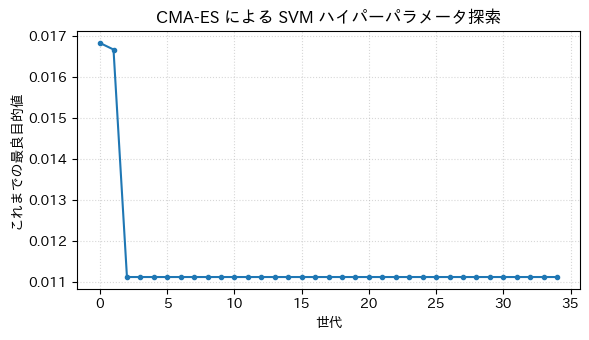

In [5]:
from collections.abc import Callable
from jaxtyping import Float, Int

from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def make_svm_objective(
    X: Float[np.ndarray, "sample feature"],
    y: Int[np.ndarray, "sample"],
) -> Callable[[Float[np.ndarray, "2"]], float]:
    """(log10 C, log10 gamma) を受け取り、範囲外ペナルティ付きの目的値を返す。"""

    lower: Float[np.ndarray, "2"] = np.array([-2.0, -4.0])
    upper: Float[np.ndarray, "2"] = np.array([3.0, 1.0])

    def objective(z: Float[np.ndarray, "2"]) -> float:
        z: Float[np.ndarray, "2"] = np.asarray(z, dtype=float)
        violation: Float[np.ndarray, "2"] = np.maximum(lower - z, 0.0) + np.maximum(z - upper, 0.0)
        penalty = 0.2 * float(np.sum(violation * violation))
        z_clip: Float[np.ndarray, "2"] = np.clip(z, lower, upper)

        C = 10.0 ** float(z_clip[0])
        gamma = 10.0 ** float(z_clip[1])
        pipe = Pipeline(
            [
                ("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=C, gamma=gamma)),
            ]
        )
        scores: Float[np.ndarray, "fold"] = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
        return 1.0 - float(np.mean(scores)) + penalty

    return objective


wine = load_wine()
X_wine: Float[np.ndarray, "sample feature"] = np.asarray(wine.data, dtype=float)
y_wine: Int[np.ndarray, "sample"] = np.asarray(wine.target, dtype=int)

svm_objective = make_svm_objective(X_wine, y_wine)
svm_optimizer, svm_history = run_cmaes(
    svm_objective,
    mean0=np.array([0.0, -2.0]),
    sigma0=1.0,
    n_generations=35,
    seed=31,
)

best_log_c, best_log_gamma = np.clip(svm_optimizer.best_x, [-2.0, -4.0], [3.0, 1.0])
best_c = 10.0 ** float(best_log_c)
best_gamma = 10.0 ** float(best_log_gamma)
best_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=best_c, gamma=best_gamma)),
    ]
)
best_acc = float(np.mean(cross_val_score(best_pipe, X_wine, y_wine, cv=5, scoring="accuracy")))

baseline_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
    ]
)
baseline_acc = float(np.mean(cross_val_score(baseline_pipe, X_wine, y_wine, cv=5, scoring="accuracy")))

print(f"ベースライン CV 精度: {baseline_acc:.4f}")
print(f"CMA-ES 最良 CV 精度（最良パラメータで再評価）: {best_acc:.4f}")
print(f"log10 C={best_log_c:.3f}, log10 gamma={best_log_gamma:.3f}")
print(f"C={best_c:.4g}, gamma={best_gamma:.4g}")

fig, ax = plt.subplots(figsize=(6.0, 3.5))
ax.plot([float(h["best_f"]) for h in svm_history], marker="o", ms=3)
ax.set_xlabel("世代")
ax.set_ylabel("これまでの最良目的値")
ax.set_title("CMA-ES による SVM ハイパーパラメータ探索")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


### Optuna の CMA-ES Sampler で 5 次元探索をする

Optuna は，機械学習モデルのハイパーパラメータ探索を自動化するための Python ライブラリである．たとえば SVM の $C$ や $\gamma$，ニューラルネットワークの学習率，木モデルの深さなど，「人間が手で調整しがちな値」を，目的関数の評価結果を見ながら効率よく探すために使う．

Optuna の基本単位は **study** と **trial** である．study は「1 つの最適化実験全体」を表し，trial は「あるハイパーパラメータの組を 1 回試すこと」を表す．ユーザーは `objective(trial)` という関数を書き，その中で `trial.suggest_float` などを使って探索したい値を指定する．その後，`study.optimize(objective, n_trials=...)` と書くと，Optuna が trial を繰り返し，最も良かったパラメータを `study.best_params` などに記録してくれる．

Optuna には，標準的な TPE だけでなく，CMA-ES を使って連続ハイパーパラメータを提案する `CmaEsSampler` も用意されている．つまり，Optuna の便利な `trial` / `study` の仕組みを使いながら，サンプリングアルゴリズムとして CMA-ES を選べる．

直前の手書き CMA-ES 実装では，アルゴリズムの動きを読みやすくするために $(\log_{10}C,\log_{10}\gamma)$ の 2 変数だけを探索した．しかし実際のハイパーパラメータ探索としては 2 変数だけでは簡単すぎる．そこで Optuna 側では，同じ Wine データセットと RBF カーネル SVM を使いつつ，次の 5 つを同時に探索する．

1. $\log_{10} C$: 誤分類へのペナルティの強さ．
2. $\log_{10}\gamma$: RBF カーネルの幅を決める値．
3. $\log_{10}\mathrm{tol}$: SVM の最適化を止める許容誤差．
4. $\log_{10}w_0$: Wine のクラス 0 に対する重み．
5. $\log_{10}w_1$: Wine のクラス 1 に対する重み．

ここで $w_0,w_1$ は `SVC(class_weight=...)` に渡す重みである．クラス 2 の重みは 1 に固定し，クラス 0 と 1 の誤分類をどれくらい重く見るかだけを探索する．このように書くと，`CmaEsSampler` が 5 次元の連続空間で次に試す点を提案している，と読める．


Optuna sampler: CmaEsSampler
探索したハイパーパラメータ数: 5
ベースライン CV 精度: 0.9833
手書き CMA-ES 最良 CV 精度: 0.9889
Optuna CMA-ES 最良 CV 精度: 0.9944
Optuna CMA-ES 最良パラメータ:
  log10_C=-0.074
  log10_gamma=-1.957
  log10_tol=-3.175
  log10_weight_class_0=0.379
  log10_weight_class_1=0.332
C=0.8425, gamma=0.01104, tol=6.69e-04
class_weight={0: 2.395, 1: 2.146, 2: 1.000}
試行回数: 120


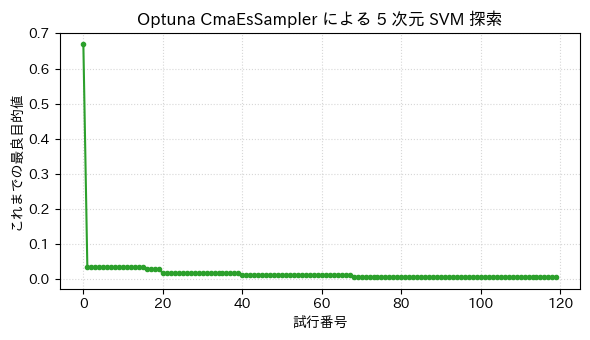

In [6]:
import warnings

warnings.filterwarnings("ignore", message="IProgress" + " not found.*")

import optuna
from optuna.samplers import CmaEsSampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_PARAM_NAMES = [
    "log10_C",
    "log10_gamma",
    "log10_tol",
    "log10_weight_class_0",
    "log10_weight_class_1",
]


def optuna_cmaes_svm_objective(trial: optuna.Trial) -> float:
    """Optuna の CmaEsSampler で 5 つの連続ハイパーパラメータを探索する。"""

    log_c = trial.suggest_float("log10_C", -2.0, 3.0)
    log_gamma = trial.suggest_float("log10_gamma", -4.0, 1.0)
    log_tol = trial.suggest_float("log10_tol", -5.0, -2.0)
    log_weight_0 = trial.suggest_float("log10_weight_class_0", -0.7, 0.7)
    log_weight_1 = trial.suggest_float("log10_weight_class_1", -0.7, 0.7)

    C = 10.0 ** float(log_c)
    gamma = 10.0 ** float(log_gamma)
    tol = 10.0 ** float(log_tol)
    class_weight = {
        0: 10.0 ** float(log_weight_0),
        1: 10.0 ** float(log_weight_1),
        2: 1.0,
    }

    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=C, gamma=gamma, tol=tol, class_weight=class_weight)),
        ]
    )
    scores: Float[np.ndarray, "fold"] = cross_val_score(pipe, X_wine, y_wine, cv=5, scoring="accuracy")
    return 1.0 - float(np.mean(scores))


optuna_cmaes_sampler = CmaEsSampler(  # Optuna に CMA-ES で次の候補点を提案させるサンプラーを作る。
    x0={  # CMA-ES の初期平均 m に相当する点を，探索変数ごとに指定する。
        "log10_C": 0.0,  # SVM の C を 10^0=1 から探索し始める。
        "log10_gamma": -2.0,  # RBF カーネルの gamma を 10^{-2} から探索し始める。
        "log10_tol": -3.0,  # SVM の停止許容誤差 tol を 10^{-3} から探索し始める。
        "log10_weight_class_0": 0.0,  # クラス 0 の重みを 10^0=1 から探索し始める。
        "log10_weight_class_1": 0.0,  # クラス 1 の重みを 10^0=1 から探索し始める。
    },  # ここまでが 5 次元の初期点 x0 である。
    sigma0=1.0,  # 初期ステップサイズ σ。log10 空間でどれくらい大きく動くかを決める。
    seed=31,  # 乱数シードを固定し，授業資料として結果を再現しやすくする。
    warn_independent_sampling=False,  # CMA-ES 開始前の独立サンプリング警告を資料上では非表示にする。
)  # サンプラーの設定はここで終わりである。
optuna_cmaes_study = optuna.create_study(  # 1 つの最適化実験を管理する Study を作る。
    direction="minimize",  # 目的関数は 1 - CV 精度なので，小さいほど良い。
    sampler=optuna_cmaes_sampler,  # 候補点の提案方法として，上で作った CMA-ES サンプラーを使う。
)  # Study には試行履歴，最良値，最良パラメータが保存される。
optuna_cmaes_study.optimize(  # ここで実際に目的関数を繰り返し評価する。
    optuna_cmaes_svm_objective,  # 各 trial で SVM を交差検証し，1 - 精度を返す関数。
    n_trials=120,  # 120 回だけ候補点を評価する。評価回数を増やすと時間も増える。
    show_progress_bar=False,  # 静的な授業ノートでは進捗バーを出さない。
)  # 最適化が終わると best_params や best_value を取り出せる。

optuna_best_params = optuna_cmaes_study.best_params
optuna_best_c = 10.0 ** float(optuna_best_params["log10_C"])
optuna_best_gamma = 10.0 ** float(optuna_best_params["log10_gamma"])
optuna_best_tol = 10.0 ** float(optuna_best_params["log10_tol"])
optuna_best_class_weight = {
    0: 10.0 ** float(optuna_best_params["log10_weight_class_0"]),
    1: 10.0 ** float(optuna_best_params["log10_weight_class_1"]),
    2: 1.0,
}
optuna_best_acc = 1.0 - float(optuna_cmaes_study.best_value)

print(f"Optuna sampler: {optuna_cmaes_study.sampler.__class__.__name__}")
print(f"探索したハイパーパラメータ数: {len(OPTUNA_PARAM_NAMES)}")
print(f"ベースライン CV 精度: {baseline_acc:.4f}")
print(f"手書き CMA-ES 最良 CV 精度: {best_acc:.4f}")
print(f"Optuna CMA-ES 最良 CV 精度: {optuna_best_acc:.4f}")
print("Optuna CMA-ES 最良パラメータ:")
for name in OPTUNA_PARAM_NAMES:
    print(f"  {name}={float(optuna_best_params[name]):.3f}")
print(f"C={optuna_best_c:.4g}, gamma={optuna_best_gamma:.4g}, tol={optuna_best_tol:.2e}")
print(
    "class_weight="
    f"{{0: {optuna_best_class_weight[0]:.3f}, "
    f"1: {optuna_best_class_weight[1]:.3f}, "
    f"2: {optuna_best_class_weight[2]:.3f}}}"
)
print(f"試行回数: {len(optuna_cmaes_study.trials)}")

trial_values: Float[np.ndarray, "trial"] = np.array([float(t.value) for t in optuna_cmaes_study.trials if t.value is not None])
best_so_far: Float[np.ndarray, "trial"] = np.minimum.accumulate(trial_values)

fig, ax = plt.subplots(figsize=(6.0, 3.5))
ax.plot(best_so_far, marker="o", ms=3, color="tab:green")
ax.set_xlabel("試行番号")
ax.set_ylabel("これまでの最良目的値")
ax.set_title("Optuna CmaEsSampler による 5 次元 SVM 探索")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


この演習では，目的関数評価のたびに 5-fold CV が走る．したがって，世代数や個体数を増やすと計算時間も増える．CMA-ES は「評価回数を使って分布を学習する」方法なので，予算を意識して使う必要がある．



(sec:cmaes-assignment)=

## 7. 課題



### 課題1：ステップサイズの違い

`mean0=np.array([3.5, 2.8])` は固定したまま，`sigma0` を `0.2`, `0.8`, `2.0` に変えて，悪スケール楕円関数の最良値推移を比較せよ．

考察では，次を含めること．

1. 小さすぎる $\sigma$ では何が起こったか．
2. 大きすぎる $\sigma$ では何が起こったか．
3. 共分散行列の楕円はどのタイミングで谷の方向へ傾いたか．



### 課題2：Optuna CmaEsSampler による SVM 以外の機械学習モデル探索

Optuna の `CmaEsSampler` を使って，自分で選んだ **SVM 以外** の機械学習モデルのハイパーパラメータ探索を行え．データセットは Wine でもよいし，`sklearn.datasets` に含まれる別のデータセットを使ってもよい．

たとえば，`RandomForestClassifier`，`GradientBoostingClassifier`，`KNeighborsClassifier`，`MLPClassifier`，`LogisticRegression` などから 1 つ選べばよい．ただし，`CmaEsSampler` は連続値の探索と相性がよいので，少なくとも 2 つ以上の数値ハイパーパラメータを `trial.suggest_float` で探索すること．整数として使いたい値は，`suggest_float` で得た値を `int(round(...))` のように変換してもよい．

考察では，次を含めること．

1. 選んだモデル名，データセット，最小化した目的関数を説明せよ．
2. 探索したハイパーパラメータの名前，範囲，その意味を説明せよ．
3. ベースライン設定と，`CmaEsSampler` で得た最良設定の性能を比較せよ．
4. 試行回数を増やすと結果は安定しそうか，計算時間との関係も含めて考察せよ．



### 課題3：Optuna CmaEsSampler による機械学習以外の最適化

Optuna の `CmaEsSampler` を使って，自分で選んだ **機械学習以外** の問題を最適化せよ．目的関数は自分で定義してよい．たとえば，Rosenbrock 関数，Rastrigin 関数，Ackley 関数，二次元の設計変数を持つコスト関数，簡単な物理シミュレーションのパラメータ調整などが候補である．

問題は，少なくとも 2 つ以上の連続変数を持つ形にすること．`trial.suggest_float` で各変数の探索範囲を指定し，`study.optimize` で目的関数を最小化する．可能なら，試行番号に対する「これまでの最良目的値」のグラフも描け．

考察では，次を含めること．

1. 最適化した問題の内容と，変数が何を表すかを説明せよ．
2. 目的関数の式，または評価値の計算方法を説明せよ．
3. 探索範囲，試行回数，最良解，最良目的値を示せ．
4. この問題で CMA-ES を使う意味があるかを，連続値・ブラックボックス・多峰性・変数間の依存関係などの観点から考察せよ．



### 発展課題：PSO との比較

第4回の PSO と CMA-ES を比較せよ．どちらも複数の候補解を使って探索するが，PSO は粒子の位置と速度を動かし，CMA-ES は候補解を発生させる探索分布 $\mathcal{N}(\boldsymbol{m},\sigma^2\boldsymbol{C})$ を更新する．この違いに注目するとよい．

比較観点は次の 5 つでよい．

1. 1 世代で持っている状態を比較せよ．PSO は各粒子の位置・速度・自己ベスト・全体ベストを持つのに対し，CMA-ES は平均 $\boldsymbol{m}$，ステップサイズ $\sigma$，共分散行列 $\boldsymbol{C}$，進化パスを持つ．それぞれ何を記憶していると言えるか．
2. 次の候補解を作る仕組みを比較せよ．PSO は既存の粒子を速度で動かすのに対し，CMA-ES は探索分布から新しい候補解をサンプリングする．この違いは「個体を動かす方法」と「分布から発生させる方法」の違いとしてどう説明できるか．
3. 良かった評価結果の使い方を比較せよ．PSO では自己ベストや全体ベストが速度更新に入る．CMA-ES では評価値の良い順に並べた上位個体が平均・ステップサイズ・共分散行列の更新に使われる．どちらが評価値の順位を強く使っているか．
4. 悪スケールな谷や斜めに傾いた谷を考えたとき，CMA-ES の共分散行列 $\boldsymbol{C}$ はどのような情報を学習できるか．PSO の速度更新だけで同じ情報を明示的に表していると言えるか．
5. 最後に，PSO と CMA-ES の得意そうな問題設定を自分の言葉で比較せよ．たとえば，実装の分かりやすさ，評価回数，連続値パラメータへの向き不向き，探索分布を可視化できるか，という観点から述べればよい．



## 8. 確認問題

1. CMA-ES の探索分布 $\mathcal{N}(\boldsymbol{m},\sigma^2\boldsymbol{C})$ において，$\boldsymbol{m}$，$\sigma$，$\boldsymbol{C}$ はそれぞれ何を表すか．
2. 上位 $\mu$ 個体の重み付き平均は，どのパラメータの更新に使われるか．
3. 進化パス $\boldsymbol{p}_{\sigma}$ は，どのような直感を表しているか．
4. 共分散行列の rank-one update と rank-$\mu$ update の違いを説明せよ．
5. CMA-ES はなぜ連続値パラメータのブラックボックス最適化として扱うのが自然か．また，組合せ最適化へ応用したい場合に表現変換が必要になる理由を短く説明せよ．




### 参考リンク

- CMA-ES の Python 実装解説（指定記事）: https://horomary.hatenablog.com/entry/2021/01/23/013508
- Hansen, *The CMA Evolution Strategy: A Tutorial*: https://arxiv.org/abs/1604.00772
- CMA-ES 公式ページ: https://cma-es.github.io/
- 第4回 PSO: https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture04-pso
- 第6回 DE: https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture06-de
- 第5回 ACO: https://rsimd.github.io/NITIC-ConbinatorialOptimization/lecture05-aco-tsp
- hiyoko1729, 「論文紹介: The CMA Evolution Strategy: A Comparing Review」: https://qiita.com/hiyoko1729/items/fece8a42033f0c6fe4b9
- codemajin, 「CMA-ES入門: 進化戦略によるブラックボックス最適化」: https://www.codemajin.net/cma-es-black-box-optimization/
- 秋本洋平, 「Evolution Strategies による連続最適化」: https://www.jstage.jst.go.jp/article/isciesci/60/7/60_292/_pdf
- Optuna 公式サイト https://optuna.org/
- Optuna 公式ドキュメント https://optuna.readthedocs.io/en/stable/
- Optuna GitHub Repository https://github.com/optuna/optuna

